## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as shc

plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('ggplot')

# Paleta de color fija para clusters: el mismo número de clúster usa siempre el
# mismo color en TODAS las gráficas del notebook (DBSCAN, Jerárquico, Parte II y
# Parte III), para poder comparar visualmente sin confusiones. El ruido de DBSCAN
# (-1) se pinta aparte en gris. (El número de clúster es arbitrario por algoritmo:
# mismo color no implica que sea el "mismo" segmento entre DBSCAN y Jerárquico.)
CLUSTER_PALETTE = plt.get_cmap('tab10').colors
COLOR_NOISE = (0.6, 0.6, 0.6, 1.0)

def cluster_colors(labels):
    return [COLOR_NOISE if l == -1 else CLUSTER_PALETTE[l % len(CLUSTER_PALETTE)] for l in labels]

def cluster_legend_handles(labels, noise_label='Ruido', label_prefix='Cluster', offset=0):
    handles = []
    for l in sorted(set(labels)):
        color = COLOR_NOISE if l == -1 else CLUSTER_PALETTE[l % len(CLUSTER_PALETTE)]
        text = noise_label if l == -1 else f'{label_prefix} {l + offset}'
        handles.append(plt.Line2D([0], [0], marker='o', linestyle='', markersize=8,
                                   markerfacecolor=color, markeredgecolor='k', label=text))
    return handles

def add_cluster_legend(ax, labels, **kwargs):
    ax.legend(handles=cluster_legend_handles(labels, **kwargs), fontsize=8, loc='best')

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido.

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [2]:
# ── 2. CARGA Y PRIMERA EXPLORACIÓN ──────────────────────────────────────────
df = pd.read_csv("./data/empowering_drinks.csv", sep="|")
print(f"Shape: {df.shape}")
display(df.head())
display(df.describe().round(3))

Shape: (153, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000,153.000,153.000,153.000,153.000
mean,0.019,0.037,0.041,0.080,-0.044
std,1.026,0.996,1.041,1.009,0.934
min,-2.434,-3.679,-1.696,-1.493,-1.634
25%,-0.816,-0.499,-1.043,-0.738,-0.799
50%,0.061,-0.024,0.212,-0.165,-0.155
75%,0.876,0.707,0.894,0.917,0.494
max,2.260,3.156,3.063,2.971,2.432


¿Están ya estandarizados?
  Medias: [ 0.019  0.037  0.041  0.08  -0.044]
  Stds:   [1.026 0.996 1.041 1.009 0.934]


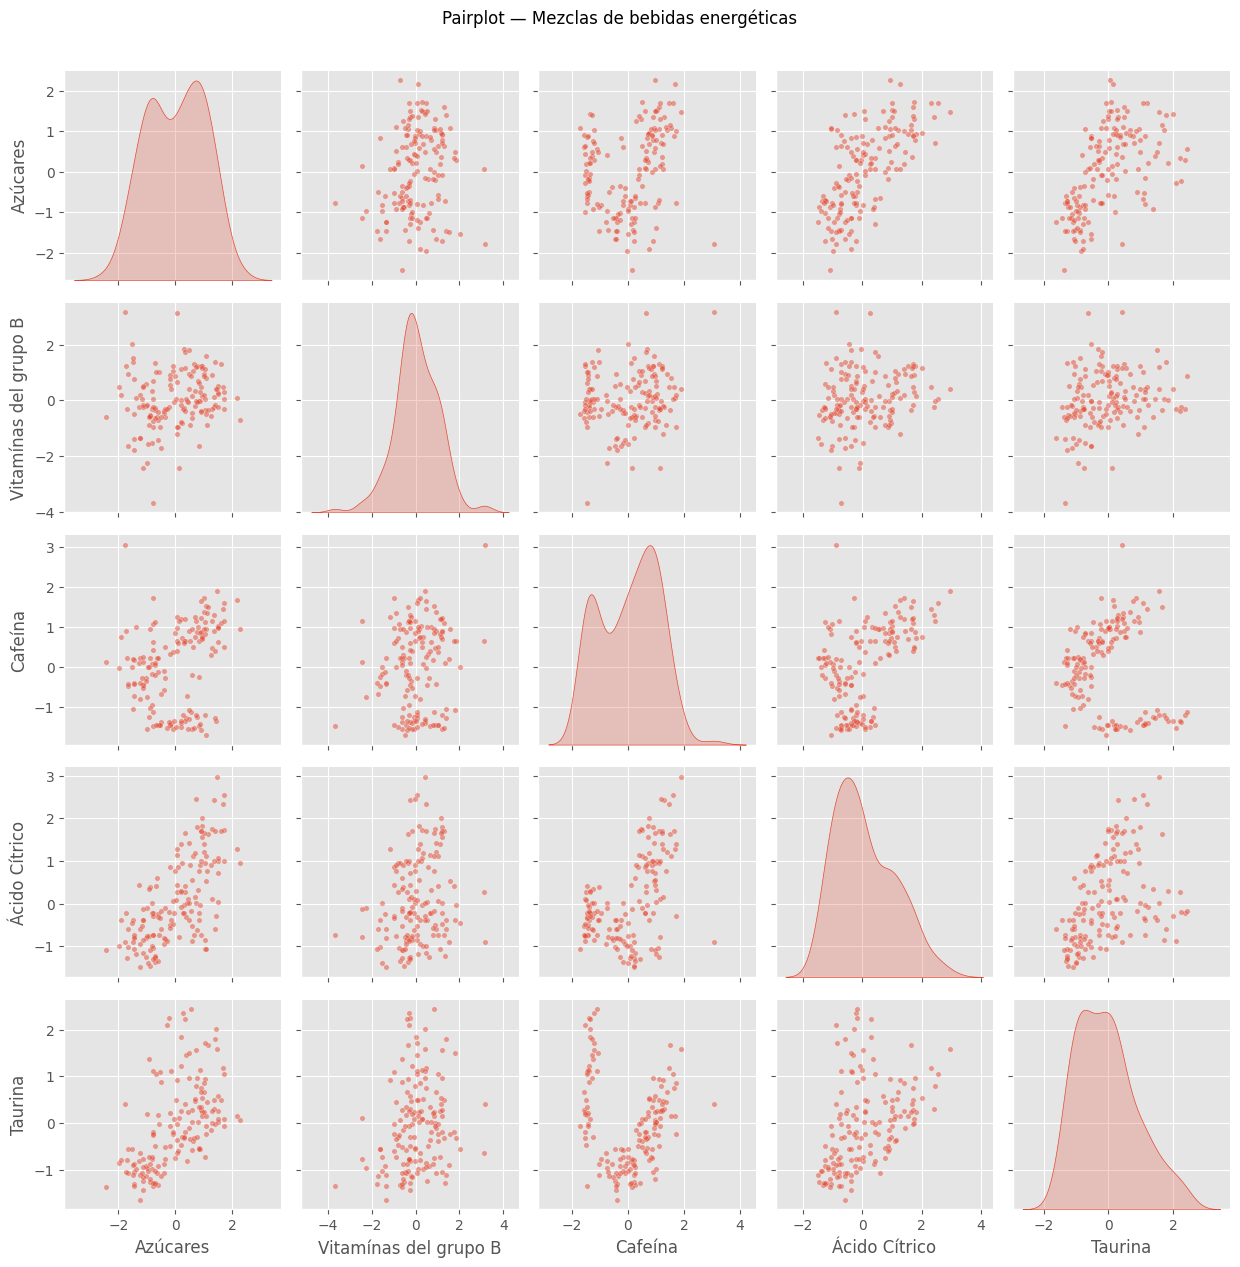

In [3]:
# ── 3. MINIEDA — Selección de features y preprocesado ───────────────────────
# Los valores parecen ya estandarizados (medias ≈ 0, std ≈ 1).
# Lo comprobamos: si se confirma, no hará falta aplicar StandardScaler más adelante.

print("¿Están ya estandarizados?")
print(f"  Medias: {df.mean().round(3).values}")
print(f"  Stds:   {df.std().round(3).values}")

# Pairplot para ver posibles agrupaciones de dos en dos
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle("Pairplot — Mezclas de bebidas energéticas", y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

**Observación:** Cafeína vs Ácido Cítrico parece mostrar la mejor separación visual.

Dataset: shape (153, 5)


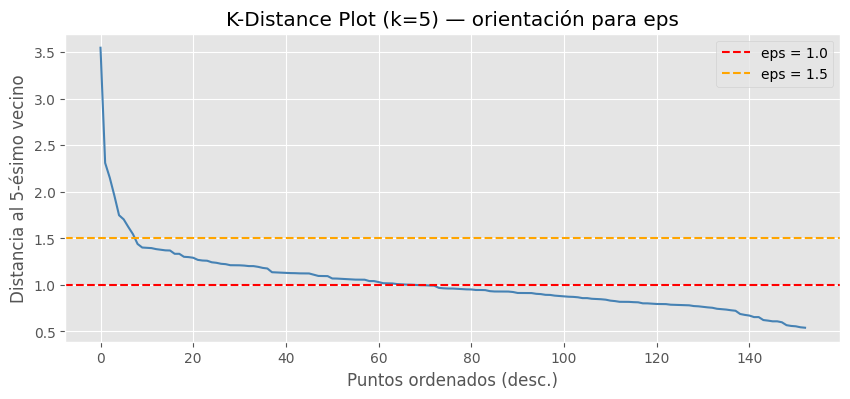

In [4]:
# ── 4. TRATAMIENTO DE FEATURES ───────────────────────────────────────────────
# Los datos ya vienen estandarizados (medias ≈ 0, std ≈ 1, ver sección anterior),
# así que no aplicamos StandardScaler: usamos directamente los valores del DataFrame.
X = df.values
print(f"Dataset: shape {X.shape}")

# K-distance plot para orientar la elección de eps en DBSCAN
# min_samples ≈ ln(n) ≈ ln(153) ≈ 5
min_s = 5
nn = NearestNeighbors(n_neighbors=min_s)
nn.fit(X)
distances, _ = nn.kneighbors(X)
distances_sorted = np.sort(distances[:, min_s-1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(distances_sorted, color='steelblue', linewidth=1.5)
plt.xlabel('Puntos ordenados (desc.)'); plt.ylabel(f'Distancia al {min_s}-ésimo vecino')
plt.title(f'K-Distance Plot (k={min_s}) — orientación para eps')
plt.axhline(y=1.0, color='red',    linestyle='--', label='eps = 1.0')
plt.axhline(y=1.5, color='orange', linestyle='--', label='eps = 1.5')
plt.legend(); plt.grid(True); plt.show()

El "codo" de la curva indica un buen valor de eps. Probaremos eps ∈ [0.8, 1.0, 1.3, 1.5, 2.0].

In [5]:
# ── 5. DBSCAN — Exploración de hiperparámetros ──────────────────────────────
# Buscamos eps y min_samples que den entre 3 y 5 clusters con poco ruido
# Criterio de selección: min_samples elegido con regla ln(n)≈5; eps del k-distance plot
# Además descartamos combinaciones con clusters "espurios" de menos de
# MIN_CLUSTER_SIZE puntos: un clúster de 2-3 mezclas no es un segmento real
# para el negocio, solo ruido interno mal etiquetado.

eps_values   = [0.8, 1.0, 1.3, 1.5, 2.0]
min_s_values = [3, 5, 7]
MIN_CLUSTER_SIZE = 5

print(f"{'eps':>5} | {'min_s':>6} | {'clusters':>8} | {'ruido %':>7} | {'tam.mín':>7} | {'silhouette':>10}")
print("-" * 60)
best_dbscan_params = None
best_sil = -1

for eps in eps_values:
    for ms in min_s_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)
        n_clusters_db = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct     = (labels == -1).sum() / len(labels) * 100
        cluster_sizes = [(labels == c).sum() for c in set(labels) if c != -1]
        min_cluster_size = min(cluster_sizes) if cluster_sizes else 0
        sizes_ok = min_cluster_size >= MIN_CLUSTER_SIZE

        if n_clusters_db >= 2:
            sil = silhouette_score(X[labels != -1], labels[labels != -1])
            marker = " ← 3-5 clust. + tam. OK" if (3 <= n_clusters_db <= 5 and sizes_ok) else ""
            print(f"{eps:5.1f} | {ms:6d} | {n_clusters_db:8d} | {noise_pct:6.1f}% | {min_cluster_size:7d} | {sil:10.4f}{marker}")

            if 3 <= n_clusters_db <= 5 and noise_pct < 20 and sizes_ok and sil > best_sil:
                best_sil = sil
                best_dbscan_params = (eps, ms)
        else:
            print(f"{eps:5.1f} | {ms:6d} | {n_clusters_db:8d} | {noise_pct:6.1f}% | {min_cluster_size:7d} | {'N/A':>10}")

print(f"\nMejores parámetros: eps={best_dbscan_params[0]}, min_samples={best_dbscan_params[1]}")
print(f"Silhouette score:   {best_sil:.4f}")

  eps |  min_s | clusters | ruido % | tam.mín | silhouette
------------------------------------------------------------
  0.8 |      3 |        7 |   35.3% |       3 |     0.2769
  0.8 |      5 |        8 |   52.3% |       4 |     0.3153
  0.8 |      7 |        4 |   68.6% |       7 |     0.5310 ← 3-5 clust. + tam. OK
  1.0 |      3 |        4 |    9.2% |       4 |     0.2413
  1.0 |      5 |        3 |   18.3% |      34 |     0.4551 ← 3-5 clust. + tam. OK
  1.0 |      7 |        3 |   33.3% |      21 |     0.5010 ← 3-5 clust. + tam. OK
  1.3 |      3 |        1 |    3.9% |     147 |        N/A
  1.3 |      5 |        1 |    3.9% |     147 |        N/A
  1.3 |      7 |        1 |    3.9% |     147 |        N/A
  1.5 |      3 |        1 |    2.6% |     149 |        N/A
  1.5 |      5 |        1 |    2.6% |     149 |        N/A
  1.5 |      7 |        1 |    2.6% |     149 |        N/A
  2.0 |      3 |        1 |    0.7% |     152 |        N/A
  2.0 |      5 |        1 |    0.7% |     15

DBSCAN final: eps=1.0, min_samples=5
  Clusters encontrados: 3  |  Ruido: 18.3%  |  Silhouette: 0.4551
  Distribución: {np.int64(-1): np.int64(28), np.int64(0): np.int64(49), np.int64(1): np.int64(42), np.int64(2): np.int64(34)}


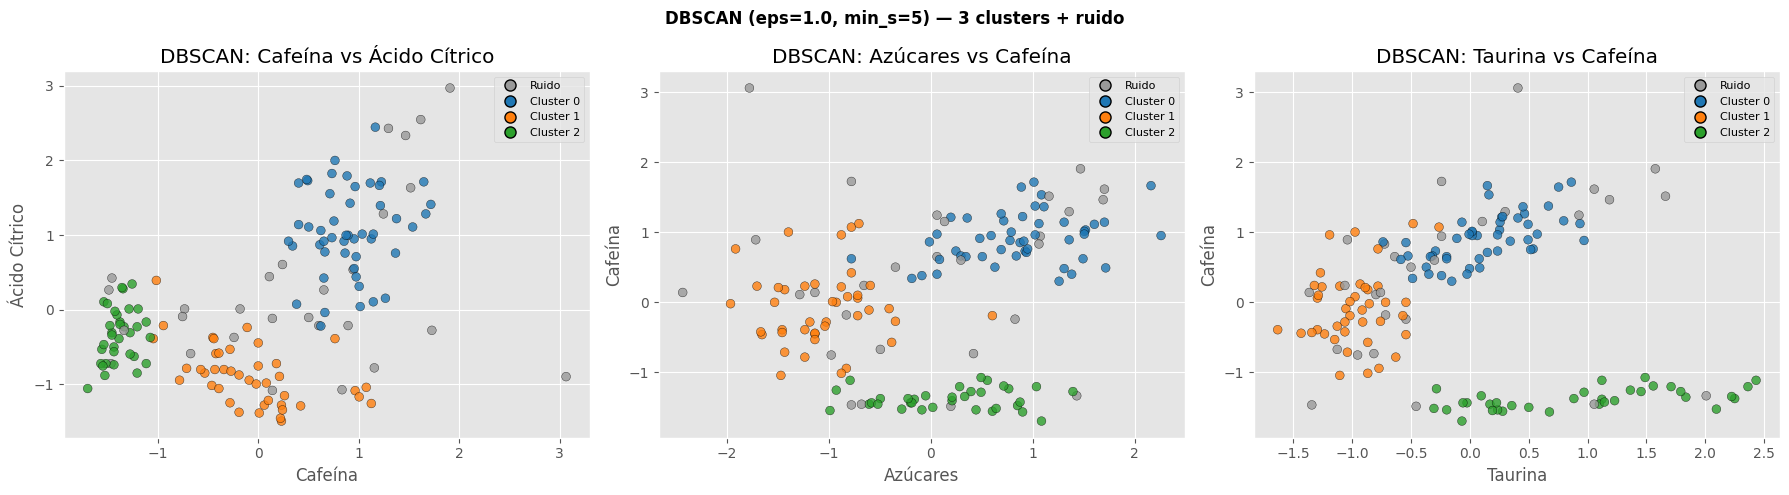

In [6]:
# ── 6. DBSCAN — Modelo final + visualización ────────────────────────────────
eps_best, ms_best = best_dbscan_params
dbscan_final  = DBSCAN(eps=eps_best, min_samples=ms_best)
labels_dbscan = dbscan_final.fit_predict(X)

n_clust_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
pct_noise  = (labels_dbscan == -1).sum() / len(labels_dbscan) * 100
sil_db     = silhouette_score(X[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])

print(f"DBSCAN final: eps={eps_best}, min_samples={ms_best}")
print(f"  Clusters encontrados: {n_clust_db}  |  Ruido: {pct_noise:.1f}%  |  Silhouette: {sil_db:.4f}")
print(f"  Distribución: {dict(zip(*np.unique(labels_dbscan, return_counts=True)))}")

# Visualización: 3 pares de features más informativos
cols  = df.columns.tolist()
pairs = [('Cafeína', 'Ácido Cítrico'), ('Azúcares', 'Cafeína'), ('Taurina', 'Cafeína')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cx, cy) in zip(axes, pairs):
    ix, iy = cols.index(cx), cols.index(cy)
    ax.scatter(X[:, ix], X[:, iy], c=cluster_colors(labels_dbscan),
               alpha=0.8, s=40, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(cx); ax.set_ylabel(cy)
    ax.set_title(f'DBSCAN: {cx} vs {cy}')
    add_cluster_legend(ax, labels_dbscan)

plt.suptitle(f'DBSCAN (eps={eps_best}, min_s={ms_best}) — {n_clust_db} clusters + ruido',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

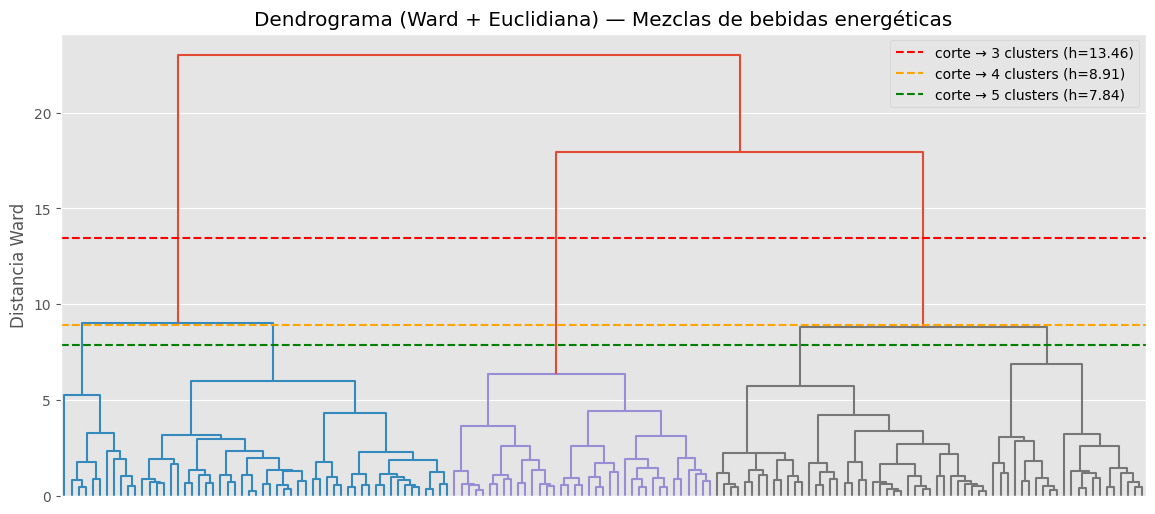

Selección de n_clusters:
  n_clusters=3 | Silhouette=0.3843 | Distribución=[55, 61, 37]
  n_clusters=4 | Silhouette=0.3369 | Distribución=[61, 44, 37, 11]
  n_clusters=5 | Silhouette=0.3037 | Distribución=[22, 44, 37, 11, 39]

Hierárquico seleccionado: 3 clusters | Silhouette = 0.3843


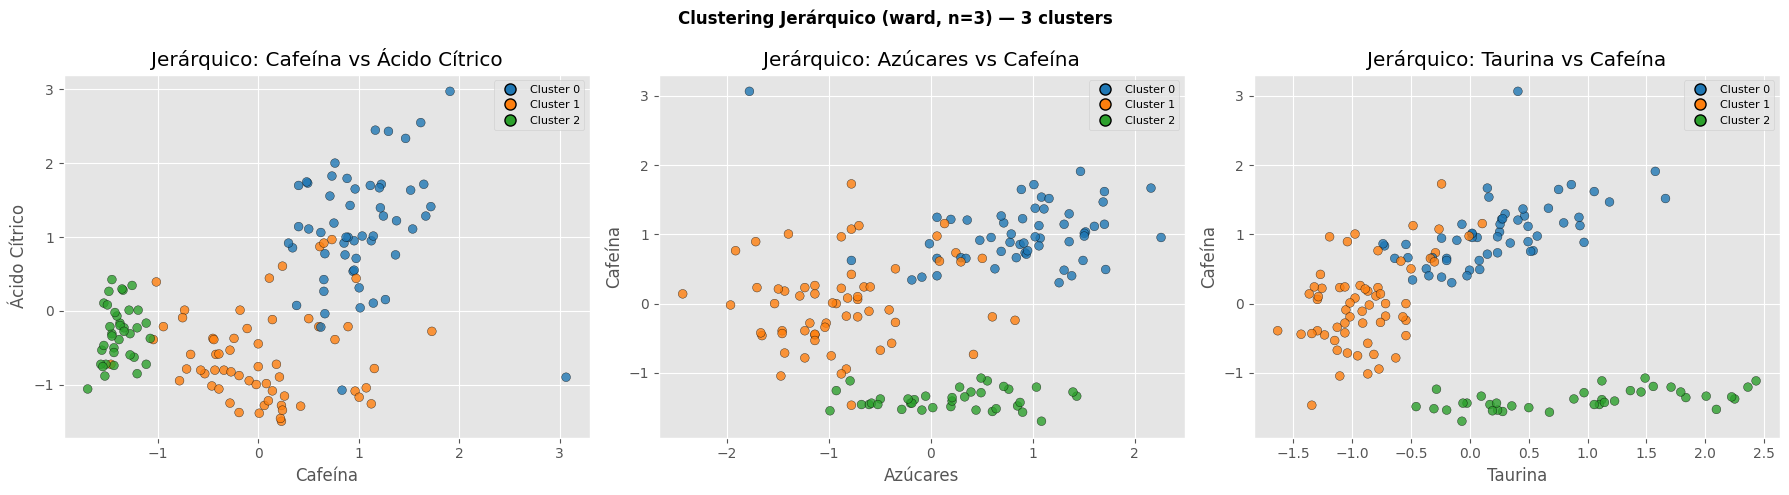

In [7]:
# ── 7. CLUSTERING JERÁRQUICO (AgglomerativeClustering) ─────────────────────
# Elegido porque los químicos quieren ver RELACIONES entre segmentos → dendrogram
# Ward minimiza la varianza intra-cluster; Euclidiana es la métrica estándar.

Z = shc.linkage(X, method='ward', metric='euclidean')
n_obs = X.shape[0]

# Altura de corte calculada dinámicamente a partir del propio linkage: para
# obtener k clusters hace falta situarse entre la fusión que deja k clusters
# y la siguiente (que los reduciría a k-1); tomamos el punto medio entre ambas.
def altura_corte(Z, k, n_obs):
    idx = n_obs - k - 1
    return (Z[idx, 2] + Z[idx + 1, 2]) / 2

colores_corte = {3: 'red', 4: 'orange', 5: 'green'}
alturas_corte = {k: altura_corte(Z, k, n_obs) for k in [3, 4, 5]}

# Dendrograma para orientar el número de clusters
plt.figure(figsize=(14, 6))
shc.dendrogram(Z, no_labels=True)
for k, h in alturas_corte.items():
    plt.axhline(y=h, color=colores_corte[k], linestyle='--',
                label=f'corte → {k} clusters (h={h:.2f})')
plt.title('Dendrograma (Ward + Euclidiana) — Mezclas de bebidas energéticas')
plt.ylabel('Distancia Ward'); plt.legend(); plt.show()

# Comparamos 3, 4 y 5 clusters por silhouette, descartando los que dejen
# clusters con menos de MIN_CLUSTER_SIZE puntos (mismo criterio que en DBSCAN)
print("Selección de n_clusters:")
sil_hc_dict = {}
for n_k in [3, 4, 5]:
    hc   = AgglomerativeClustering(n_clusters=n_k, metric='euclidean', linkage='ward')
    labs = hc.fit_predict(X)
    sizes = np.bincount(labs)
    sizes_ok = sizes.min() >= MIN_CLUSTER_SIZE
    sil  = silhouette_score(X, labs)
    if sizes_ok:
        sil_hc_dict[n_k] = sil
    marker = "" if sizes_ok else "  ← descartado (clúster < tam. mínimo)"
    print(f"  n_clusters={n_k} | Silhouette={sil:.4f} | Distribución={sizes.tolist()}{marker}")

best_n_hc  = max(sil_hc_dict, key=sil_hc_dict.get)
hc_final   = AgglomerativeClustering(n_clusters=best_n_hc, metric='euclidean', linkage='ward')
labels_hc  = hc_final.fit_predict(X)
sil_hc     = silhouette_score(X, labels_hc)
print(f"\nHierárquico seleccionado: {best_n_hc} clusters | Silhouette = {sil_hc:.4f}")

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cx, cy) in zip(axes, pairs):
    ix, iy = cols.index(cx), cols.index(cy)
    ax.scatter(X[:, ix], X[:, iy], c=cluster_colors(labels_hc),
               alpha=0.8, s=40, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(cx); ax.set_ylabel(cy)
    ax.set_title(f'Jerárquico: {cx} vs {cy}')
    add_cluster_legend(ax, labels_hc)

plt.suptitle(f'Clustering Jerárquico (ward, n={best_n_hc}) — {best_n_hc} clusters',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [8]:
# ── 8. COMPARACIÓN DBSCAN vs JERÁRQUICO ─────────────────────────────────────
print("=" * 65)
print("COMPARACIÓN: DBSCAN vs Clustering Jerárquico Aglomerativo")
print("=" * 65)
print(f"  DBSCAN:       eps={eps_best}, min_s={ms_best} | {n_clust_db} clusters | ruido={pct_noise:.0f}% | Sil={sil_db:.4f}")
print(f"  Jerárquico:   ward+euclidean | {best_n_hc} clusters  | sin ruido   | Sil={sil_hc:.4f}")

COMPARACIÓN: DBSCAN vs Clustering Jerárquico Aglomerativo
  DBSCAN:       eps=1.0, min_s=5 | 3 clusters | ruido=18% | Sil=0.4551
  Jerárquico:   ward+euclidean | 3 clusters  | sin ruido   | Sil=0.3843


**¿Por qué es especulativa la comparación?**
No existe ground truth: no sabemos qué segmentación es "correcta"; el silhouette es solo una medida interna (cohesión vs separación).

**Ventajas DBSCAN:**
- Detecta automáticamente ruido/outliers
- No asume forma esférica de los clusters
- No hay que fijar k a priori

**Ventajas Jerárquico** (elegido según el enunciado):
- El dendrograma muestra RELACIONES entre segmentos (pedido explícito)
- No tiene puntos de ruido → clasifica todos los experimentos
- Muy explicable al cliente

**Recomendación final:** usar el Jerárquico para segmentar y presentar la jerarquía a los químicos, y DBSCAN como detector de mezclas atípicas para estudio especial.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

Nuevos experimentos: (6, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782



Segmentación de los 6 nuevos experimentos:
segmento
0    2
1    2
2    2


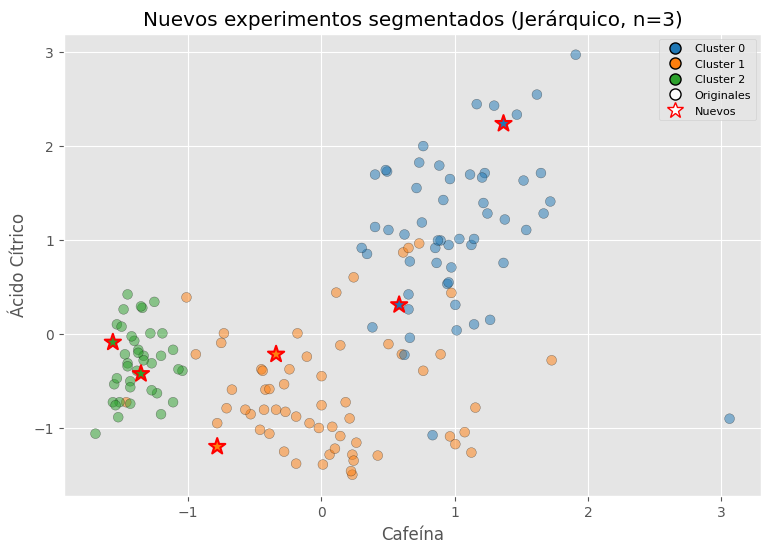

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,segmento
0,1.481555,0.305159,1.366128,2.239039,0.731870,0
1,0.616869,0.890014,0.583034,0.312420,-0.665332,0
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,1
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,1
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,2


In [13]:
# PARTE II — Clasificar nuevos experimentos
# Usamos el Clustering Jerárquico (más sencillo: todos los puntos quedan asignados)
# NOTA: AgglomerativeClustering no tiene .predict(), así que reentrenamos con todos los datos.

# Cargamos los nuevos experimentos
df_new = pd.read_csv("./data/new_experiments.csv", sep="|")
print(f"Nuevos experimentos: {df_new.shape}")
display(df_new.head(3))

# Los nuevos experimentos ya están en la misma escala que los originales (no hace falta escalar)
X_new = df_new.values

# Concatenamos original + nuevos y reentrenamos el clustering jerárquico
X_all    = np.vstack([X, X_new])
hc_all   = AgglomerativeClustering(n_clusters=best_n_hc, metric='euclidean', linkage='ward')
labels_all = hc_all.fit_predict(X_all)

# Las etiquetas de los nuevos experimentos son las últimas filas
labels_new = labels_all[len(X):]
labels_orig_retrain = labels_all[:len(X)]

df_new['segmento'] = labels_new
print(f"\nSegmentación de los {len(df_new)} nuevos experimentos:")
print(df_new['segmento'].value_counts().sort_index().to_string())

# Visualización: scatter Cafeína vs Ácido Cítrico con originales + nuevos
# (mismos colores de clúster que en el resto del notebook; la forma distingue origen)
ix = cols.index('Cafeína'); iy = cols.index('Ácido Cítrico')
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X[:, ix],     X[:, iy],     c=cluster_colors(labels_orig_retrain),
           alpha=0.5, s=50,  edgecolors='k', linewidths=0.3)
ax.scatter(X_new[:, ix], X_new[:, iy], c=cluster_colors(labels_new),
           alpha=1.0, s=150, edgecolors='red', linewidths=1.5, marker='*')
ax.set_xlabel('Cafeína'); ax.set_ylabel('Ácido Cítrico')
ax.set_title(f'Nuevos experimentos segmentados (Jerárquico, n={best_n_hc})')

handles = cluster_legend_handles(np.concatenate([labels_orig_retrain, labels_new]))
handles += [plt.Line2D([0], [0], marker='o', linestyle='', markersize=8,
                        markerfacecolor='white', markeredgecolor='k', label='Originales'),
            plt.Line2D([0], [0], marker='*', linestyle='', markersize=12,
                        markerfacecolor='white', markeredgecolor='red', label='Nuevos')]
ax.legend(handles=handles, fontsize=8, loc='best')
plt.show()

display(df_new)

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

In [10]:
# PARTE III EXTRA — Evaluación con ground truth (6 meses después)
# power_results.csv: clase 1=media, 2=media-alta, 3=alta.
# El fichero tiene 159 filas: las 153 mezclas originales + las 6 de "new_experiments.csv"
# (ver enunciado de la Parte III). Usamos solo las 153 primeras para evaluar los
# modelos de la Parte I, que es el conjunto sobre el que se entrenaron.

df_results = pd.read_csv("./data/power_results.csv")
y_true_all = df_results['class'].values - 1   # 0-indexed para comparar con clusters
y_true     = y_true_all[:len(X)]              # las 153 mezclas originales
print(f"Clases reales (originales): {np.unique(y_true+1, return_counts=True)}")

# ── Evaluación del Clustering Jerárquico ──────────────────────────────────
# adjusted_rand_score: mide similitud entre clustering y etiquetas reales
# (independiente de la permutación de etiquetas)
ari_hc = adjusted_rand_score(y_true, labels_hc)
print(f"\nAdjusted Rand Index — Jerárquico (n={best_n_hc}):  {ari_hc:.4f}")

# ── Evaluación del DBSCAN (excluyendo ruido) ─────────────────────────────
mask_noise = labels_dbscan != -1
ari_db = adjusted_rand_score(y_true[mask_noise], labels_dbscan[mask_noise])
print(f"Adjusted Rand Index — DBSCAN (sin ruido):         {ari_db:.4f}")

# ── Evaluación para los distintos n_clusters del jerárquico ──────────────
print("\nComparación para distintos n_clusters (Jerárquico):")
for n_k in [3, 4, 5]:
    hc_eval = AgglomerativeClustering(n_clusters=n_k, metric='euclidean', linkage='ward')
    labs    = hc_eval.fit_predict(X)
    ari     = adjusted_rand_score(y_true, labs)
    sil     = silhouette_score(X, labs)
    print(f"  n_clusters={n_k} | ARI={ari:.4f} | Silhouette={sil:.4f}")

Clases reales (originales): (array([1, 2, 3]), array([56, 60, 37]))

Adjusted Rand Index — Jerárquico (n=3):  0.8160
Adjusted Rand Index — DBSCAN (sin ruido):         0.9484

Comparación para distintos n_clusters (Jerárquico):
  n_clusters=3 | ARI=0.8160 | Silhouette=0.3843
  n_clusters=4 | ARI=0.7845 | Silhouette=0.3369
  n_clusters=5 | ARI=0.6751 | Silhouette=0.3037


**Nota:** ARI = 0 indica asignación aleatoria; ARI = 1 indica clustering perfecto. Valores positivos indican que el clustering captura algo de la estructura real.

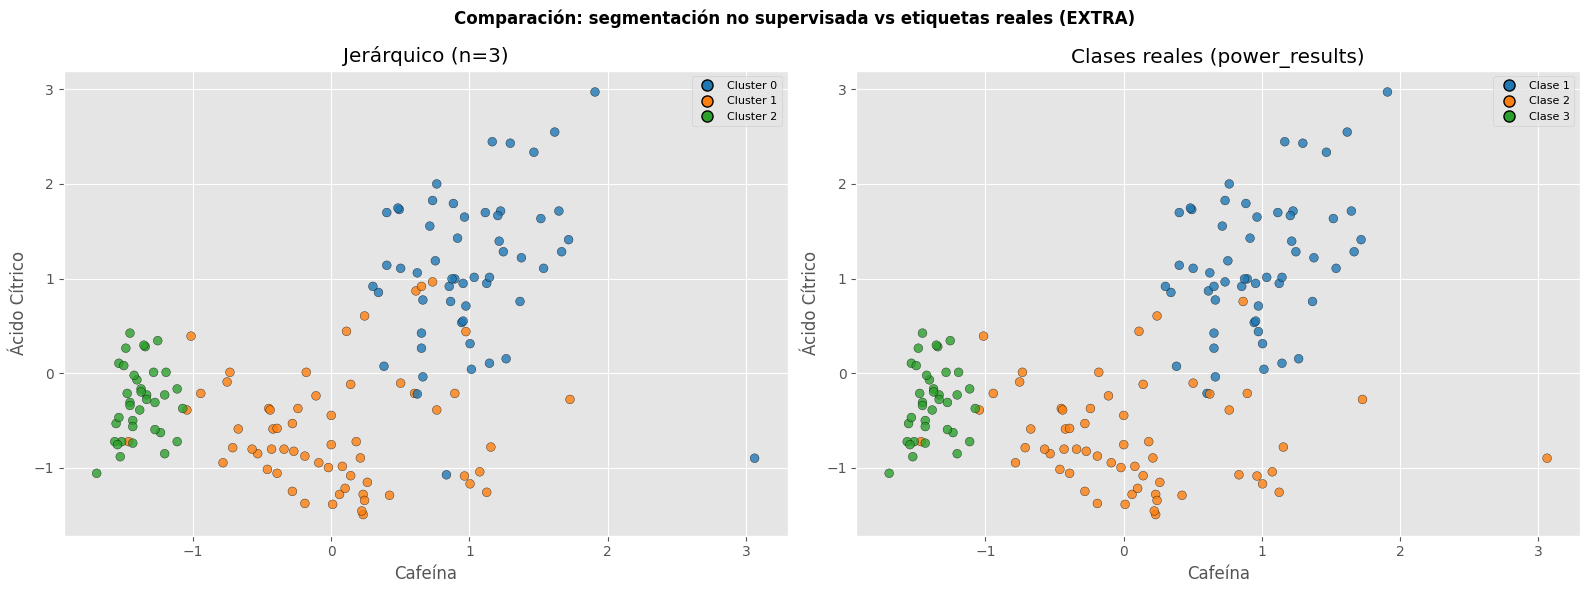

In [11]:
# ── Visualización: clusters vs clases reales ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ix, iy = cols.index('Cafeína'), cols.index('Ácido Cítrico')

axes[0].scatter(X[:, ix], X[:, iy], c=cluster_colors(labels_hc), alpha=0.8, s=40,
                edgecolors='k', linewidths=0.3)
axes[0].set_xlabel('Cafeína'); axes[0].set_ylabel('Ácido Cítrico')
axes[0].set_title(f'Jerárquico (n={best_n_hc})')
add_cluster_legend(axes[0], labels_hc)

axes[1].scatter(X[:, ix], X[:, iy], c=cluster_colors(y_true), alpha=0.8, s=40,
                edgecolors='k', linewidths=0.3)
axes[1].set_xlabel('Cafeína'); axes[1].set_ylabel('Ácido Cítrico')
axes[1].set_title('Clases reales (power_results)')
add_cluster_legend(axes[1], y_true, label_prefix='Clase', offset=1)

plt.suptitle('Comparación: segmentación no supervisada vs etiquetas reales (EXTRA)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()